# Dados do INEP (2005 - 2021) 

### Análise exploratória de dados do INEP (Instituto Nacional de Estudos e Pesquisas Educacionais Anísio Teixeira), para buscar entender padrões e gerar insights.

# 1 - Visão geral dos dados e importação de pacotes 

In [1]:
# limpeza e análise 
import pandas as pd 
import numpy as np 

# vizualização de dados 
import matplotlib.pyplot as plt 
import seaborn as sns

# ignorar avisos
import warnings
warnings.simplefilter('ignore')


In [2]:
# carregando os dados em um Pandas dataframe
df = pd.read_csv(r"C:\Users\renil\Desktop\dadosINEP\Data\br_inep_ideb_brasil.csv")
# imprime as cinco primeiras linhas do dataframe
df.head(5)

,ano,rede,ensino,anos_escolares,taxa_aprovacao,indicador_rendimento,nota_saeb_matematica,nota_saeb_lingua_portuguesa,nota_saeb_media_padronizada,ideb,projecao
0,2009,total,medio,todos (1-4),75.9,0.795302,274.72,268.82,4.572342,3.6,3.5
1,2013,total,medio,todos (1-4),80.1,0.823323,270.14,264.05,4.436750,3.7,3.9
2,2021,total,medio,todos (1-4),90.8,0.900923,271.00,275.97,4.626981,4.2,NaN
3,2007,total,medio,todos (1-4),74.1,0.778403,272.89,261.39,4.435226,3.5,3.4
4,2017,total,medio,todos (1-4),83.1,0.838888,270.63,268.51,4.510258,3.8,4.7


In [3]:
# colunas que constituem o dataframe e seus respectivos tipos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ano                          126 non-null    int64  
 1   rede                         126 non-null    object 
 2   ensino                       126 non-null    object 
 3   anos_escolares               126 non-null    object 
 4   taxa_aprovacao               126 non-null    float64
 5   indicador_rendimento         126 non-null    float64
 6   nota_saeb_matematica         126 non-null    float64
 7   nota_saeb_lingua_portuguesa  126 non-null    float64
 8   nota_saeb_media_padronizada  126 non-null    float64
 9   ideb                         126 non-null    float64
 10  projecao                     98 non-null     float64
dtypes: float64(7), int64(1), object(3)
memory usage: 11.0+ KB


In [4]:
# 2 - Limpeza e preparação de dados

In [5]:
# removendo colunas que não serão uteis nessa análise
df.drop(columns=[col for col in ['nota_saeb_media_padronizada', 'projecao', 'indicador_rendimento'] if col in df.columns], inplace=True)

In [6]:
# procurando por valores nulos
df.isna().sum()

ano                            0
rede                           0
ensino                         0
anos_escolares                 0
taxa_aprovacao                 0
nota_saeb_matematica           0
nota_saeb_lingua_portuguesa    0
ideb                           0
dtype: int64

# 3 Análise exploratória (EDA)

## 3.1 Entendendo melhor a distribuição de dados e identificando possíveis outliers

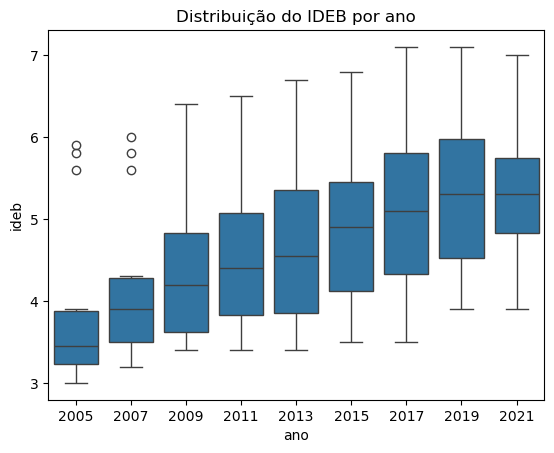

In [7]:
sns.boxplot(x='ano', y='ideb', data=df)
plt.title('Distribuição do IDEB por ano')
plt.show()

## 3.2 Evolução do IDEB (Índice de Desenvolvimento da Educação Básica) ao longo dos anos (2005 - 2021)

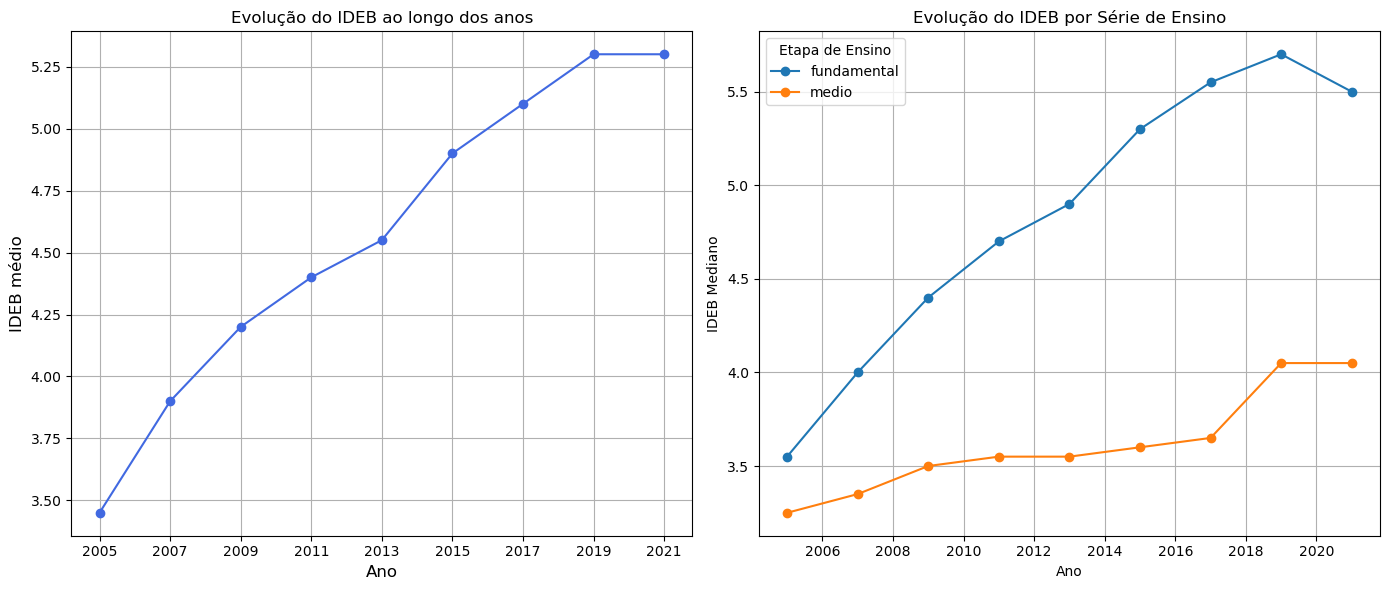

In [8]:
# Agrupamentos
ideb_por_ano = df.groupby('ano')['ideb'].median()
ideb_por_ensino = df.groupby(['ano', 'ensino'])['ideb'].median().unstack()

# Criando os subplots: 1 linha, 2 colunas
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Evolução do IDEB ao longo dos anos
axs[0].plot(ideb_por_ano.index, ideb_por_ano.values, marker="o", linestyle="-", color='royalblue')
axs[0].set_title("Evolução do IDEB ao longo dos anos")
axs[0].set_xlabel("Ano", fontsize=12)
axs[0].set_ylabel("IDEB médio", fontsize=12)
axs[0].grid(True)
axs[0].set_xticks(ideb_por_ano.index)

# Gráfico 2: Evolução do IDEB por Série de Ensino (com legenda corrigida)
axs[1].set_title('Evolução do IDEB por Série de Ensino')
for etapa in ideb_por_ensino.columns:
    axs[1].plot(ideb_por_ensino.index, ideb_por_ensino[etapa], marker='o', label=etapa)

axs[1].set_xlabel('Ano')
axs[1].set_ylabel('IDEB Mediano')
axs[1].grid(True)
axs[1].legend(title='Etapa de Ensino')

# Ajustando layout e exibindo os gráficos
plt.tight_layout()
plt.show()


## 3.3 Evolução do IDEB por rede (pública e privada)

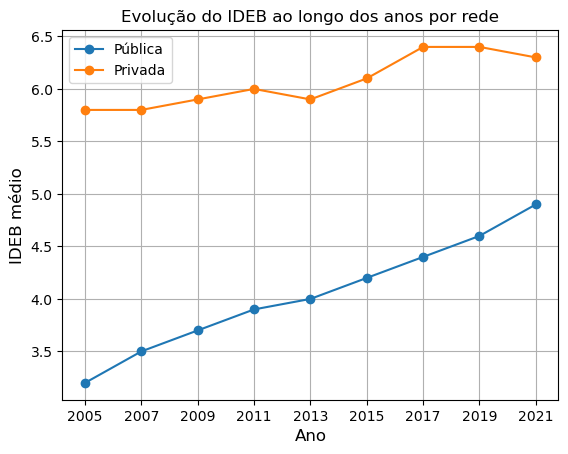

In [9]:
taxa_por_rede = df.groupby(['ano', 'rede'])['ideb'].median().unstack()

plt.plot(taxa_por_rede.index, taxa_por_rede['publica'], marker="o", linestyle="-", label='Pública')
plt.plot(taxa_por_rede.index, taxa_por_rede['privada'], marker="o", linestyle="-", label='Privada')
plt.title("Evolução do IDEB ao longo dos anos por rede")
plt.xlabel("Ano", fontsize=12)
plt.ylabel("IDEB médio", fontsize=12)
plt.grid(True)
plt.xticks(taxa_por_rede.index)
plt.legend()
plt.show()



## 3.4 Porcentagem de aprovação geral

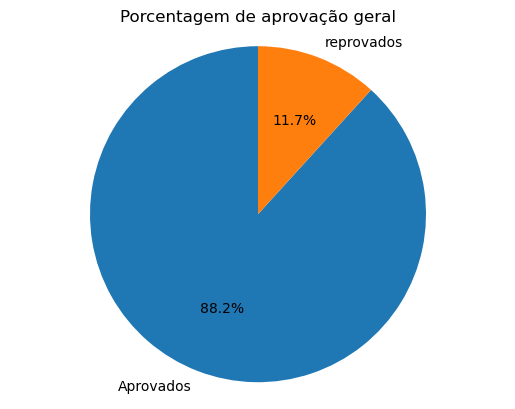

In [10]:
media_taxa = df['taxa_aprovacao'].median()

# calculando a media de aprovados e reorovados
aprovados = media_taxa
reprovados = 100 - media_taxa

valores = [aprovados, reprovados]
labels = ['Aprovados' , 'reprovados']
colors = ['mediumseagreen', 'tomato']

plt.pie(valores, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Porcentagem de aprovação geral')
plt.axis('equal')  
plt.show()

## 3.5 Porcentagem de aprovação por rede (pública e privada)

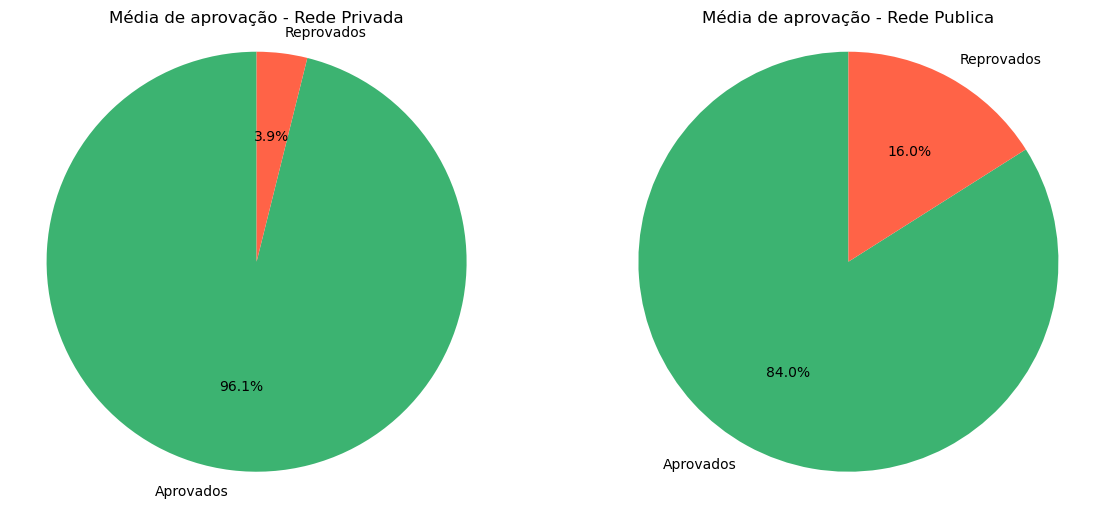

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

media_taxa_privada = df[df['rede'] == 'privada']['taxa_aprovacao'].mean()
media_taxa_publica = df[df['rede'] == 'publica']['taxa_aprovacao'].mean()


# Criando os valores para o gráfico
aprovados = media_taxa_privada
reprovados = 100 - media_taxa_privada
valores = [aprovados, reprovados]

# criando os valores para o segundo gráfico
aprovados2 = media_taxa_publica
reprovados2 = 100 - media_taxa_publica
valores2 = [aprovados2, reprovados2]

# Labels e cores
labels = ['Aprovados', 'Reprovados']
colors = ['mediumseagreen', 'tomato']

# Plotando o gráfico de pizza
axs[0].pie(valores, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
axs[0].set_title('Média de aprovação - Rede Privada')
axs[0].axis('equal')

# plotando o segundo grafico de pizza
axs[1].pie(valores2, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
axs[1].set_title('Média de aprovação - Rede Publica')
axs[1].axis('equal')

plt.show()

## 3.6 Notas do SAEB (Sistema de Avaliação da Educação Básica) ao longo dos anos

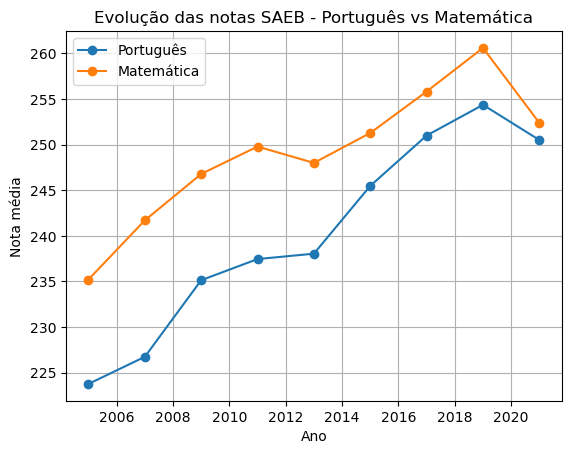

In [12]:
# filtrando notas do SAEB por ano
notas_por_ano = df.pivot_table(index='ano', values=['nota_saeb_lingua_portuguesa', 'nota_saeb_matematica'])

notas_por_ano.plot(marker='o')
plt.title('Evolução das notas SAEB - Português vs Matemática')
plt.xlabel('Ano')
plt.ylabel('Nota média')
plt.grid(True)
plt.legend(['Português', 'Matemática'])
plt.show()

## 3.7 Comparativo de Notas do SAEB por Rede e Etapa Escolar 

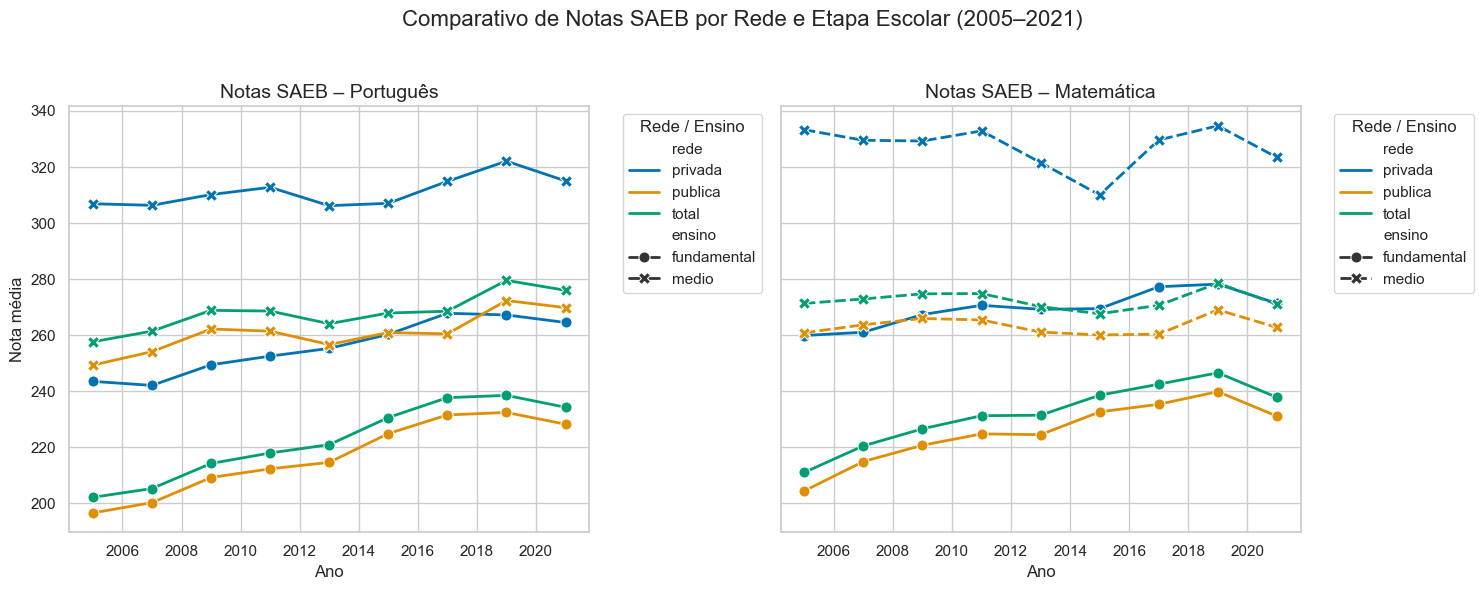

In [13]:
# Agrupamento
df_grouped = df.groupby(['ano', 'rede', 'ensino']).agg({
    'nota_saeb_lingua_portuguesa': 'mean',
    'nota_saeb_matematica': 'mean'
}).reset_index()

#  Filtrar apenas redes desejadas
redes_desejadas = ['publica', 'privada', 'total']
df_grouped = df_grouped[df_grouped['rede'].isin(redes_desejadas)]

# Estilo e paletas mais acessíveis
sns.set(style="whitegrid")
paleta_portugues = sns.color_palette("colorblind", n_colors=df_grouped['rede'].nunique())
paleta_matematica = sns.color_palette("colorblind", n_colors=df_grouped['rede'].nunique())

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# --- Português ---
sns.lineplot(
    data=df_grouped,
    x='ano',
    y='nota_saeb_lingua_portuguesa',
    hue='rede',
    style='ensino',
    markers=True,
    markersize=8,
    linewidth=2,
    dashes=False,
    palette=paleta_portugues,
    ax=axes[0]
)
axes[0].set_title('Notas SAEB – Português', fontsize=14)
axes[0].set_xlabel('Ano', fontsize=12)
axes[0].set_ylabel('Nota média', fontsize=12)

# Matemática 
sns.lineplot(
    data=df_grouped,
    x='ano',
    y='nota_saeb_matematica',
    hue='rede',
    style='ensino',
    markers=True,
    markersize=8,
    linewidth=2,
    dashes=True,
    palette=paleta_matematica,
    ax=axes[1]
)
axes[1].set_title('Notas SAEB – Matemática', fontsize=14)
axes[1].set_xlabel('Ano', fontsize=12)
axes[1].set_ylabel('')

# Legendas
axes[0].legend(title='Rede / Ensino', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].legend(title='Rede / Ensino', bbox_to_anchor=(1.05, 1), loc='upper left')

# Título geral
fig.suptitle('Comparativo de Notas SAEB por Rede e Etapa Escolar (2005–2021)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# 3.8 Medindo a correlação das variáveis

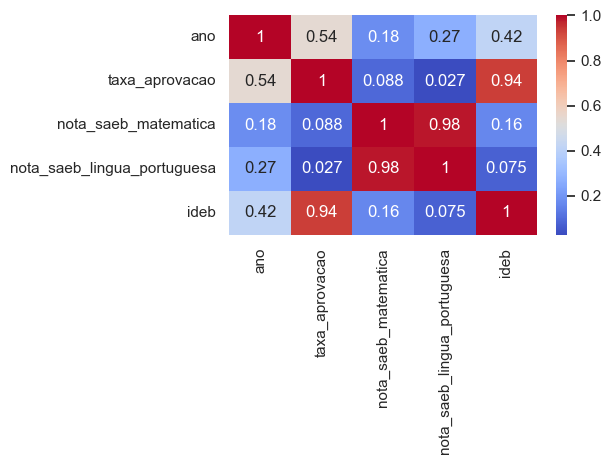

In [14]:
# selecionando apenas colunas nunericas
df_numerico = df.select_dtypes(include='number')

# calculando matriz de correlação
matriz_corr = df_numerico.corr()

# exibindo dados
sns.heatmap(matriz_corr, annot= True, cmap= "coolwarm")
plt.tight_layout()
plt.show()

# 4 Conclusão (Insights chave)

### --> Desigualdade clara: escolas privadas seguem com médias mais altas que as públicas.

### --> Português x Matemática: alunos têm notas melhores em Português, mostrando uma dificuldade maior em Matemática.

### --> Pandemia (2020–2021): o período marcou uma queda no desempenho, ligada ao ensino remoto e à dificuldade de acesso à tecnologia, principalmente na rede pública.

### --> Taxas de reprovação: os dados mostram que a reprovação é mais alta na rede pública, reforçando o impacto das desigualdades de aprendizagem.

### --> Grupos vulneráveis: há alunos com notas muito abaixo da média, evidenciando desigualdades internas e situações de maior fragilidade.

### --> A maior parte dos alunos vai melhor em português do que em matemática, revelando uma possível fragilidade estrutural na área de exatas em nosso país.

### --> O IDEB da rede pública cresceu significamente mais ao longo dos anos, em quanto o IDEB da rede privada se mostrou um pouco mais estagnado em algumas épocas.

### --> Mais recentemente a distãncia entre a rede pública e privada diminuiu levemente, o que pode demonstrar impacto positivo de algumas medidas governamentais.

### --> Observando a distrbuição dos dados é possível identificar valores fora da curva que puxam a média pra baixo, indicando a existência de grupos em situação de extrema vulnerabilidade social, mas é possível observar também que essses grupos tem diminuido.